In [3]:
!python -c "import pandas, numpy, sklearn, nltk, matplotlib, seaborn, joblib; print('All libraries installed successfully')"

All libraries installed successfully


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string
import re

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [5]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

DATASET_PATH = DATA_DIR / "Resume.csv"

print("Project Root:", PROJECT_ROOT)
print("Dataset Path:", DATASET_PATH)

Project Root: E:\cse learing\ML\Ai-resume-screening\ML
Dataset Path: E:\cse learing\ML\Ai-resume-screening\ML\data\Resume.csv


In [6]:
df = pd.read_csv(DATASET_PATH)

In [7]:
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2484, 4)


In [8]:
df.head(5)

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [9]:
df.columns.tolist()

['ID', 'Resume_str', 'Resume_html', 'Category']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [12]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [13]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Count,Missing Percentage
ID,0,0.0
Resume_str,0,0.0
Resume_html,0,0.0
Category,0,0.0


In [14]:
empty_resume_count = (
    df["Resume_str"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty resumes:", empty_resume_count)

Empty resumes: 1


In [15]:
empty_category_count = (
    df["Category"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty categories:", empty_category_count)

Empty categories: 0


In [16]:
df_clean = df.copy()

In [17]:
df_clean = df_clean.dropna(
    subset=["Resume_str", "Category"]
)

In [18]:
df_clean = df_clean[
    (df_clean["Resume_str"].str.strip() != "") &
    (df_clean["Category"].str.strip() != "")
]

In [19]:
df_clean = df_clean.reset_index(drop=True)

In [20]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (2484, 4)
Cleaned shape: (2483, 4)


In [21]:
df_clean = df_clean[
    ["Resume_str", "Category"]
].copy()

In [22]:
print(df_clean.columns.tolist())

['Resume_str', 'Category']


In [23]:
duplicate_count = df_clean["Resume_str"].duplicated().sum()

print("Duplicate resumes:", duplicate_count)

Duplicate resumes: 2


In [24]:
duplicate_groups = (
    df_clean
    .groupby("Resume_str")["Category"]
    .nunique()
)

conflicting_duplicates = duplicate_groups[
    duplicate_groups > 1
]

print(
    "Duplicate resumes with conflicting categories:",
    len(conflicting_duplicates)
)

Duplicate resumes with conflicting categories: 0


In [25]:
df_clean = df_clean.drop_duplicates(
    subset=["Resume_str"],
    keep="first"
).reset_index(drop=True)

In [26]:
print("Shape after duplicate removal:", df_clean.shape)

Shape after duplicate removal: (2481, 2)


In [27]:
PROCESSED_DATA_DIR = DATA_DIR / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [28]:
CLEAN_DATASET_PATH = (
    PROCESSED_DATA_DIR / "cleaned_resume_dataset.csv"
)

df_clean.to_csv(
    CLEAN_DATASET_PATH,
    index=False
)

print("Cleaned dataset saved to:")
print(CLEAN_DATASET_PATH)

Cleaned dataset saved to:
E:\cse learing\ML\Ai-resume-screening\ML\data\processed\cleaned_resume_dataset.csv


In [31]:
category_counts = df_clean["Category"].value_counts()

category_counts.to_frame(name="Resume Count")

,Resume Count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,119
ADVOCATE,118
ACCOUNTANT,118
ENGINEERING,118
CHEF,118
FINANCE,117
FITNESS,117
AVIATION,116


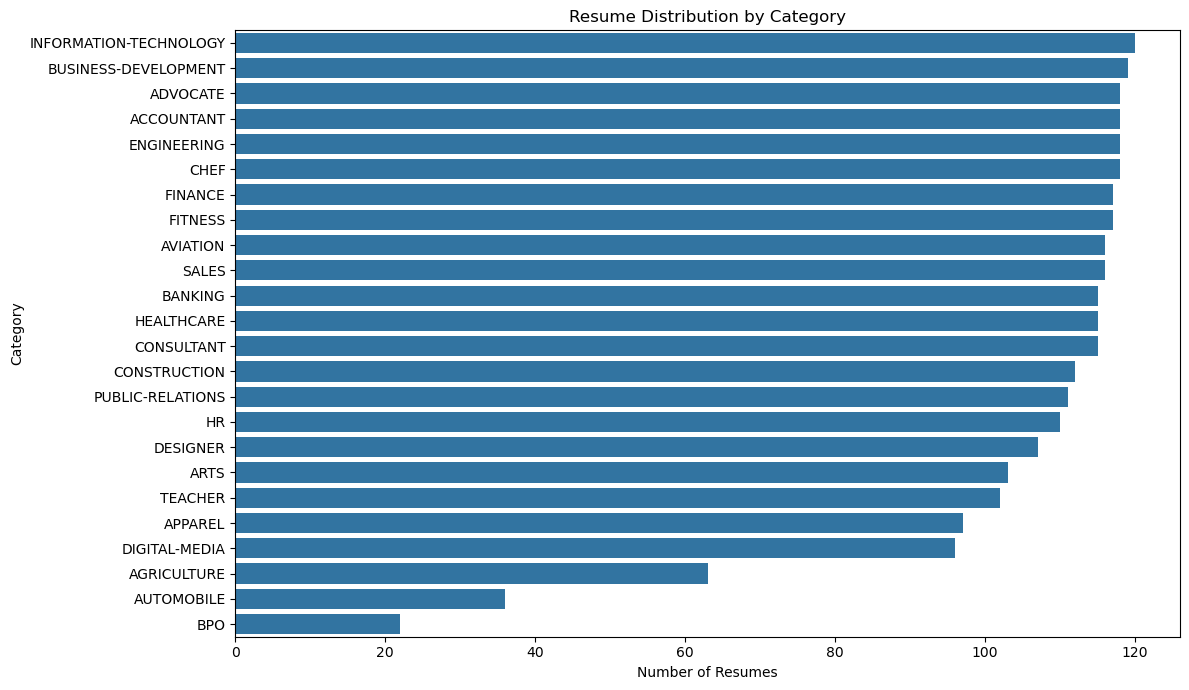

In [32]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.title("Resume Distribution by Category")

plt.tight_layout()
plt.show()

In [33]:
category_distribution = pd.DataFrame({
    "Count": df_clean["Category"].value_counts(),
    "Percentage": (
        df_clean["Category"].value_counts(normalize=True) * 100
    ).round(2)
})

category_distribution

,Count,Percentage
Category,,
INFORMATION-TECHNOLOGY,120,4.84
BUSINESS-DEVELOPMENT,119,4.80
ADVOCATE,118,4.76
ACCOUNTANT,118,4.76
ENGINEERING,118,4.76
CHEF,118,4.76
FINANCE,117,4.72
FITNESS,117,4.72
AVIATION,116,4.68


In [34]:
df_clean["text_length"] = df_clean["Resume_str"].str.len()

In [36]:
df_clean["text_length"].describe()

count     2481.000000
mean      6298.708585
std       2767.887922
min        881.000000
25%       5160.000000
50%       5888.000000
75%       7228.000000
max      38842.000000
Name: text_length, dtype: float64

In [37]:
short_resumes = df_clean[
    df_clean["text_length"] < 100
]

print("Resumes shorter than 100 characters:",
      len(short_resumes))

Resumes shorter than 100 characters: 0


In [38]:
length_by_category = (
    df_clean
    .groupby("Category")["text_length"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

length_by_category

,count,mean,median,min,max
Category,,,,,
BPO,22,7317.681818,6848.5,3317,16223
INFORMATION-TECHNOLOGY,120,7227.550000,6633.0,2062,20561
HEALTHCARE,115,6996.182609,6174.0,1954,21316
PUBLIC-RELATIONS,111,6913.432432,6059.0,2099,35933
CONSULTANT,115,6844.347826,6440.0,1710,15411
HR,110,6760.763636,5992.5,2077,24834
CONSTRUCTION,112,6618.455357,6047.5,881,30055
AGRICULTURE,63,6605.285714,5980.0,1560,14612
ADVOCATE,118,6575.161017,5843.0,2136,20975


In [39]:
url_pattern = r"(https?://\S+|www\.\S+)"

url_count = df_clean["Resume_str"].str.contains(
    url_pattern,
    regex=True,
    na=False
).sum()

print("Resumes containing URLs:", url_count)

Resumes containing URLs: 98


In [40]:
html_pattern = r"<[^>]+>"

html_count = df_clean["Resume_str"].str.contains(
    html_pattern,
    regex=True,
    na=False
).sum()

print("Resumes containing HTML-like tags:", html_count)

Resumes containing HTML-like tags: 8


In [41]:
html_examples = df_clean[
    df_clean["Resume_str"].str.contains(
        html_pattern,
        regex=True,
        na=False
    )
]

html_examples[["Resume_str", "Category"]].head()

,Resume_str,Category
626,BUSINESS DEVELOPMENT CENTER MANAGER ...,BUSINESS-DEVELOPMENT
1263,DIGITAL CONSULTANT Summary ...,DIGITAL-MEDIA
1422,CHEF OWNER Executive Profile ...,CHEF
1576,SR. FINANCE MANAGER Summary ...,FINANCE
1702,ENGINEERING INTERN Summary A...,ENGINEERING


In [42]:
df_clean = df_clean.drop(
    columns=["text_length"]
)

In [43]:
df_clean.to_csv(
    CLEAN_DATASET_PATH,
    index=False
)

print("Updated cleaned dataset saved.")

Updated cleaned dataset saved.


## Text Preprocessing

In [44]:
import re
import string

In [45]:
def clean_resume_text(text):
    """
    Clean resume text for NLP processing.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(
        r"(https?://\S+|www\.\S+)",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )

    # Replace punctuation with spaces
    text = text.translate(
        str.maketrans(
            string.punctuation,
            " " * len(string.punctuation)
        )
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [46]:
df_clean["cleaned_resume"] = (
    df_clean["Resume_str"]
    .apply(clean_resume_text)
)
df_clean[
    ["Resume_str", "cleaned_resume"]
].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [47]:
empty_cleaned = (
    df_clean["cleaned_resume"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty cleaned resumes:", empty_cleaned)

Empty cleaned resumes: 0


In [49]:
df_clean[
    df_clean["cleaned_resume"].str.strip().eq("")
    
][["Resume_str","Category"]].head()

,Resume_str,Category


In [51]:
df_clean["original_length"] = (
    df_clean["Resume_str"].str.len()
)

df_clean["cleaned_length"] = (
    df_clean["cleaned_resume"].str.len()
)

average_original = df_clean["original_length"].mean()
average_cleaned = df_clean["cleaned_length"].mean()

print(f"Average original length: {average_original:.2f}")
print(f"Average cleaned length: {average_cleaned:.2f}")

reduction = (
    (average_original - average_cleaned)
    / average_original
) * 100

print(f"Average reduction: {reduction:.2f}%")

Average original length: 6298.71
Average cleaned length: 5772.87
Average reduction: 8.35%


In [52]:
technical_terms = [
    "python",
    "java",
    "sql",
    "django",
    "react",
    "javascript",
    "aws",
    "docker",
    "machine learning",
    "accounting"
]

for term in technical_terms:
    count = df_clean["cleaned_resume"].str.contains(
        term,
        regex=False,
        na=False
    ).sum()

    print(f"{term:20} : {count}")

python               : 40
java                 : 98
sql                  : 191
django               : 0
react                : 35
javascript           : 56
aws                  : 302
docker               : 3
machine learning     : 12
accounting           : 559


In [54]:
import nltk

from nltk.corpus import stopwords

In [55]:
stop_words = set(stopwords.words("english"))

In [56]:
from collections import Counter

all_words = []

for text in df_clean["cleaned_resume"]:
    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    all_words.extend(words)

word_counts = Counter(all_words)

In [57]:
top_words = word_counts.most_common(30)

top_words

[('state', 16148),
 ('company', 15204),
 ('city', 15064),
 ('management', 12167),
 ('name', 11732),
 ('sales', 8273),
 ('customer', 7919),
 ('business', 7863),
 ('skills', 7716),
 ('－', 6890),
 ('new', 6404),
 ('service', 6218),
 ('team', 6066),
 ('development', 5728),
 ('training', 5633),
 ('experience', 5625),
 ('project', 5358),
 ('work', 4804),
 ('manager', 4531),
 ('information', 4501),
 ('marketing', 4488),
 ('financial', 4219),
 ('office', 4174),
 ('support', 4118),
 ('education', 4090),
 ('including', 4044),
 ('staff', 3946),
 ('professional', 3854),
 ('data', 3795),
 ('system', 3694)]

In [58]:
df_clean = df_clean.drop(
    columns=[
        "original_length",
        "cleaned_length"
    ]
)
print(df_clean.columns.tolist())

['Resume_str', 'Category', 'cleaned_resume']


In [59]:
PREPROCESSED_DATASET_PATH = (
    DATA_DIR
    / "processed"
    / "preprocessed_resume_dataset.csv"
)

In [60]:
df_clean.to_csv(
    PREPROCESSED_DATASET_PATH,
    index=False
)

print("Preprocessed dataset saved to:")
print(PREPROCESSED_DATASET_PATH)

Preprocessed dataset saved to:
E:\cse learing\ML\Ai-resume-screening\ML\data\processed\preprocessed_resume_dataset.csv
